# Мультимодальный RAG: пример1.pdf

Данный ноутбук демонстрирует полный пайплайн мультимодальной RAG-системы на примере файла **пример1.pdf**.

**Этапы:**
1. Загрузка и анализ структуры документа
2. Извлечение и анализ изображений
3. Построение Markdown и разбиение на чанки
4. Создание эмбеддингов и индексация в FAISS
5. Вопрос-ответная система (RAG)
6. Оценка качества ответов

In [1]:
import sys, os, logging
sys.path.insert(0, os.path.abspath('..'))
os.environ['PYTHONPATH'] = os.path.abspath('..')
logging.basicConfig(level=logging.WARNING)

import fitz
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display, Markdown, Image as IPImage

from src.pipeline.page_analyzer import PageAnalyzer
from src.preprocessing.markdown_builder import MarkdownBuilder
from src.preprocessing.image_extractor import ImageExtractor
from src.preprocessing.chart_analyzer import ChartAnalyzer
from src.preprocessing.ocr_processor import OCRProcessor
from src.rag.chunker import MarkdownChunker
from src.rag.embedder import MultimodalEmbedder
from src.rag.vector_store import FAISSVectorStore
from src.rag.retriever import MultimodalRetriever
from src.rag.generator import RAGGenerator
from src.evaluation.metrics import evaluate_response

PDF_PATH = '../data/input_pdfs/пример1.pdf'
INDEX_DIR = '../data/indexes/primer1'
IMAGES_DIR = '../data/images/primer1'
REPORT_IMG = '../report/img'
os.makedirs(INDEX_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(REPORT_IMG, exist_ok=True)

print(f'PDF: {PDF_PATH}')
print(f'Файл существует: {os.path.exists(PDF_PATH)}')

PDF: ../data/input_pdfs/пример1.pdf
Файл существует: True


---
## 1. Анализ структуры документа

Извлекаем блоки из каждой страницы PDF и классифицируем их по типам.

In [2]:
doc = fitz.open(PDF_PATH)
analyzer = PageAnalyzer()

all_blocks = []
for page_num in range(len(doc)):
    page = doc[page_num]
    page_blocks = analyzer.analyze_page(page, page_num + 1)
    all_blocks.extend(page_blocks)

print(f'Количество страниц: {len(doc)}')
print(f'Общее количество блоков: {len(all_blocks)}')

type_counts = Counter(b.block_type for b in all_blocks)
print(f'\nРаспределение блоков по типам:')
for btype, count in type_counts.most_common():
    print(f'  {btype}: {count}')

doc.close()

Количество страниц: 12
Общее количество блоков: 170

Распределение блоков по типам:
  paragraph: 94
  list_item: 48
  table: 16
  header: 9
  image: 3


Сохранено: primer1_block_types.png


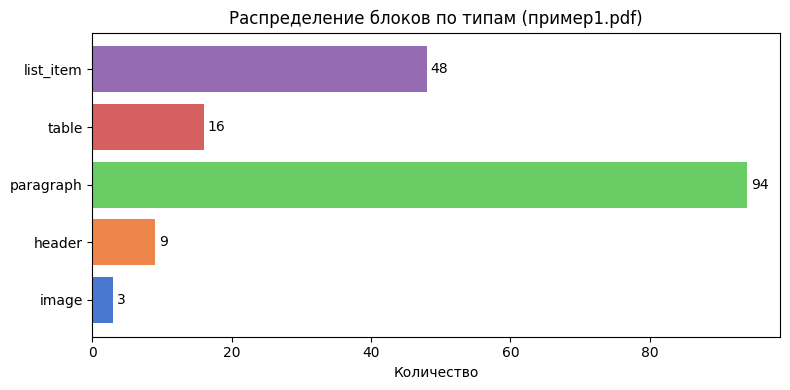

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
types = list(type_counts.keys())
counts = list(type_counts.values())
colors = sns.color_palette('muted', len(types))
bars = ax.barh(types, counts, color=colors)
ax.set_xlabel('Количество')
ax.set_title('Распределение блоков по типам (пример1.pdf)')
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(REPORT_IMG, 'primer1_block_types.png'), dpi=150, bbox_inches='tight')
print(f'Сохранено: primer1_block_types.png')
plt.show()

In [4]:
shown_types = set()
print('Примеры блоков каждого типа:')
print('=' * 60)
for block in all_blocks:
    if block.block_type not in shown_types:
        shown_types.add(block.block_type)
        print(f'\nТип: {block.block_type} | Страница: {block.page_num}')
        text_preview = (block.text or '')[:200]
        print(f'Текст: {text_preview}')
        print('-' * 60)
    if len(shown_types) == len(type_counts):
        break

Примеры блоков каждого типа:

Тип: image | Страница: 1
Текст: 
------------------------------------------------------------

Тип: header | Страница: 1
Текст: МОСКОВСКИЙ   ГОСУДАРСТВЕННЫЙ   УНИВЕРСИТЕТ   ИМЕНИ М.   В.   ЛОМОНОСОВА
------------------------------------------------------------

Тип: paragraph | Страница: 1
Текст: Разработка   модели   преобразования   речи   на казахском   языке   в   текст
------------------------------------------------------------

Тип: table | Страница: 3
Текст: Современные технологии обработки естественного языка и распознавания речи стре- мительно   развиваются,   находя   применение   во   множестве   сфер   —   от   голосовых   ас- систентов   до   автома
------------------------------------------------------------

Тип: list_item | Страница: 4
Текст: •   Конволюционного   энкодера,   преобразующего   сырые   аудиосигналы   в   скрытые представления;
------------------------------------------------------------


---
## 2. Извлечение и анализ изображений

In [5]:
extractor = ImageExtractor(min_width=50, min_height=50)
extracted_images = extractor.extract_from_pdf(PDF_PATH, output_dir=IMAGES_DIR)

summary = extractor.get_summary(extracted_images)
print(f'Извлечено изображений: {summary["total"]}')
print(f'Страницы с изображениями: {summary.get("pages_list", [])}')
if summary['total'] > 0:
    print(f'Средний размер: {summary["avg_size"]}')

Извлечено изображений: 3
Страницы с изображениями: [1, 9, 10]
Средний размер: (1263, 741)


Сохранено: primer1_images_preview.png


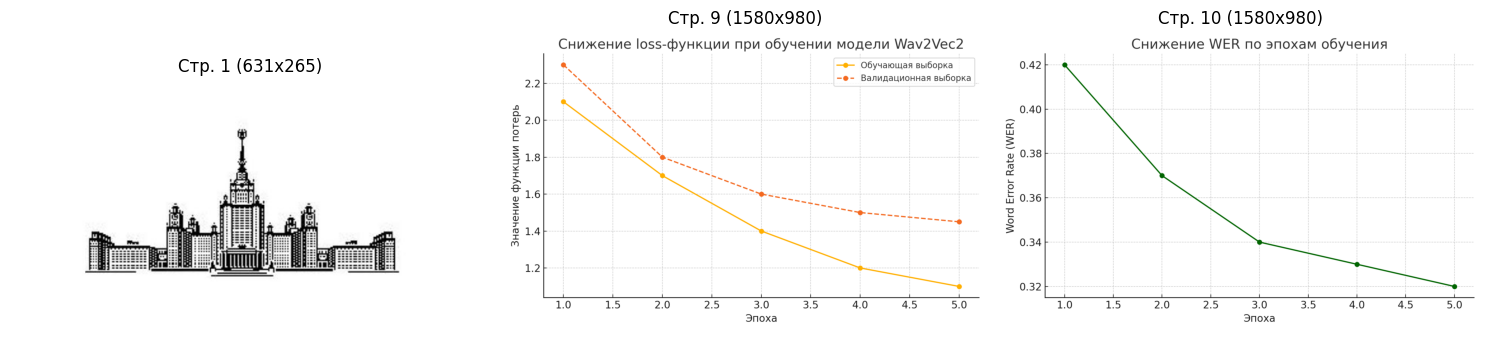

In [6]:
if extracted_images:
    n_show = min(3, len(extracted_images))
    fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
    if n_show == 1:
        axes = [axes]
    for i, img_data in enumerate(extracted_images[:n_show]):
        axes[i].imshow(img_data.image)
        axes[i].set_title(f'Стр. {img_data.page_num + 1} ({img_data.width}x{img_data.height})')
        axes[i].axis('off')
    plt.tight_layout()
    fig.savefig(os.path.join(REPORT_IMG, 'primer1_images_preview.png'), dpi=150, bbox_inches='tight')
    print(f'Сохранено: primer1_images_preview.png')
    plt.show()
else:
    print('Изображения не найдены в документе.')

In [7]:
ocr = OCRProcessor()
chart_analyzer = ChartAnalyzer(ocr_processor=ocr, use_clip=True, use_opencv=True, use_blip=True)

analyses = []
if extracted_images:
    analyses = chart_analyzer.analyze_batch(extracted_images)
    print(f'Проанализировано изображений: {len(analyses)}')
    for a in analyses:
        print(f'\n  Стр. {a.page_num}: {a.chart_type_ru} (уверенность: {a.confidence:.0%})')
        if a.blip_caption:
            print(f'  BLIP описание: {a.blip_caption}')
        if a.ocr_text:
            print(f'  OCR текст: {a.ocr_text[:150]}...')
else:
    print('Изображений для анализа нет.')

ERROR:src.preprocessing.ocr_processor:OCR failed: tesseract is not installed or it's not in your PATH. See README file for more information.


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


ERROR:src.preprocessing.ocr_processor:OCR failed: tesseract is not installed or it's not in your PATH. See README file for more information.


ERROR:src.preprocessing.ocr_processor:OCR failed: tesseract is not installed or it's not in your PATH. See README file for more information.


Проанализировано изображений: 3

  Стр. 1: Гистограмма (уверенность: 52%)
  BLIP описание: this image shows a black and white drawing of a city

  Стр. 9: Гистограмма (уверенность: 64%)
  BLIP описание: this image shows a graph of the average number of people in the world

  Стр. 10: Гистограмма (уверенность: 27%)
  BLIP описание: this image shows a graph of the average time of a person to go to work


---
## 3. Построение Markdown и разбиение на чанки

In [8]:
builder = MarkdownBuilder()
markdown = builder.build(all_blocks, source_name='пример1.pdf')
builder.save(markdown, os.path.join(INDEX_DIR, 'пример1.pdf.md'))

print(f'Markdown: {len(markdown)} символов')
print(f'\nПервые 500 символов Markdown:')
print(markdown[:500])

Markdown: 23328 символов

Первые 500 символов Markdown:
# пример1.pdf


---
*Страница 1*

![Изображение со стр. 1](image_p1)

## МОСКОВСКИЙ   ГОСУДАРСТВЕННЫЙ   УНИВЕРСИТЕТ   ИМЕНИ М.   В.   ЛОМОНОСОВА

## КАЗАХСТАНСКИЙ   ФИЛИАЛ

## ФАКУЛЬТЕТ   ВЫЧИСЛИТЕЛЬНОЙ   МАТЕМАТИКИ   И КИБЕРНЕТИКИ

Разработка   модели   преобразования   речи   на казахском   языке   в   текст

## КУРСОВАЯ   РАБОТА

Выполнил: Магистрант,   ПМИМ-1 Мухамедияр   Адиль

Научный   руководитель: Доцент   кафедры,   к.ф.-м.н. Смирнов   Илья   Николаевич

Астана 2025


---
*Страница 2*



In [9]:
chunker = MarkdownChunker(max_chunk_size=1000, chunk_overlap=100, min_chunk_size=50)
chunks = chunker.chunk_markdown(markdown, source='пример1.pdf')

image_chunks = []
if analyses:
    image_chunks = chunker.create_image_chunks(analyses, source='пример1.pdf')
    chunks.extend(image_chunks)

text_chunks = [c for c in chunks if c.chunk_type == 'text']
table_chunks = [c for c in chunks if c.chunk_type == 'table']
img_chunks = [c for c in chunks if c.chunk_type == 'image_caption']

print(f'Всего чанков: {len(chunks)}')
print(f'  - текстовых: {len(text_chunks)}')
print(f'  - табличных: {len(table_chunks)}')
print(f'  - из изображений: {len(img_chunks)}')

Всего чанков: 36
  - текстовых: 2
  - табличных: 30
  - из изображений: 4


Сохранено: primer1_chunk_sizes.png


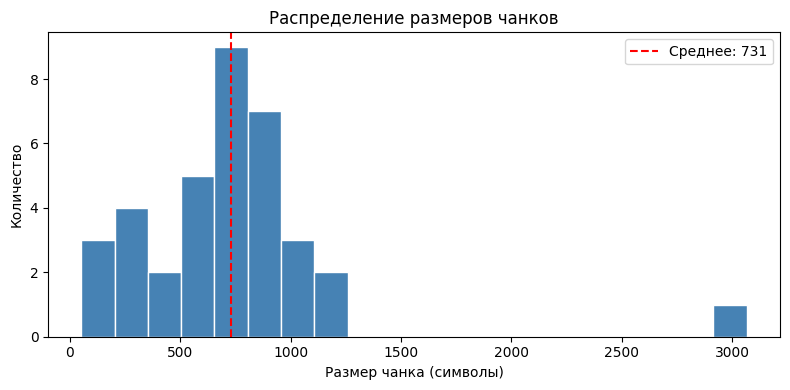

Мин. размер: 52 символов
Макс. размер: 3066 символов
Средний размер: 731 символов


In [10]:
sizes = [len(c.text) for c in chunks]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sizes, bins=20, color='steelblue', edgecolor='white')
ax.set_xlabel('Размер чанка (символы)')
ax.set_ylabel('Количество')
ax.set_title('Распределение размеров чанков')
ax.axvline(np.mean(sizes), color='red', linestyle='--', label=f'Среднее: {np.mean(sizes):.0f}')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(REPORT_IMG, 'primer1_chunk_sizes.png'), dpi=150, bbox_inches='tight')
print(f'Сохранено: primer1_chunk_sizes.png')
plt.show()

print(f'Мин. размер: {min(sizes)} символов')
print(f'Макс. размер: {max(sizes)} символов')
print(f'Средний размер: {np.mean(sizes):.0f} символов')

In [11]:
print('Пример текстового чанка:')
print('=' * 60)
if text_chunks:
    c = text_chunks[0]
    print(f'ID: {c.chunk_id}')
    print(f'Тип: {c.chunk_type}')
    print(f'Страница: {c.page}')
    print(f'Раздел: {c.section}')
    print(f'Размер: {len(c.text)} символов')
    print(f'Текст:\n{c.text[:300]}')

if img_chunks:
    print('\n\nПример чанка из изображения:')
    print('=' * 60)
    c = img_chunks[0]
    print(f'ID: {c.chunk_id}')
    print(f'Тип: {c.chunk_type}')
    print(f'Страница: {c.page}')
    print(f'Текст:\n{c.text[:300]}')

Пример текстового чанка:
ID: 9b6876c6
Тип: text
Страница: None
Раздел: ФАКУЛЬТЕТ   ВЫЧИСЛИТЕЛЬНОЙ   МАТЕМАТИКИ   И КИБЕРНЕТИКИ
Размер: 78 символов
Текст:
Разработка   модели   преобразования   речи   на казахском   языке   в   текст


Пример чанка из изображения:
ID: db3b6d90
Тип: image_caption
Страница: 1
Текст:
---
*Страница 1*

![Изображение со стр. 1](image_p1)


---
## 4. Эмбеддинги и индексация в FAISS

Создаем векторные представления чанков с помощью мультиязычной модели
paraphrase-multilingual-MiniLM-L12-v2 и сохраняем в FAISS-индекс.

In [12]:
embedder = MultimodalEmbedder(use_clip=False)
print(f'Модель: {embedder.text_embedder.model_name}')
print(f'Размерность эмбеддинга: {embedder.dimension}')

embeddings = embedder.embed_chunks(chunks)
print(f'Матрица эмбеддингов: {embeddings.shape}')

vector_store = FAISSVectorStore(dimension=embedder.dimension)
metadata_list = [c.to_dict() for c in chunks]
vector_store.add(embeddings, metadata_list)
vector_store.save(INDEX_DIR)

print(f'Векторов в индексе: {vector_store.size}')
print(f'Индекс сохранен: {INDEX_DIR}')

Модель: paraphrase-multilingual-MiniLM-L12-v2


Размерность эмбеддинга: 384


Матрица эмбеддингов: (36, 384)
Векторов в индексе: 36
Индекс сохранен: ../data/indexes/primer1


Сохранено: primer1_tsne.png


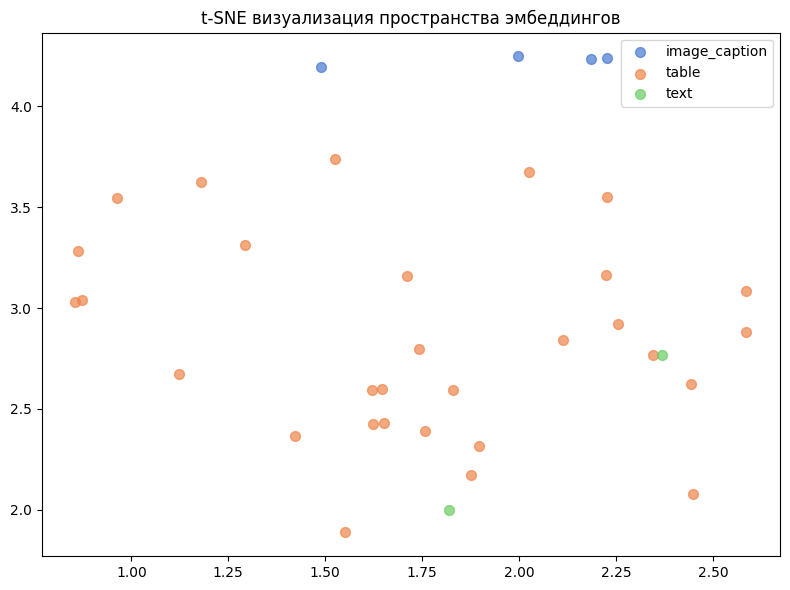

In [13]:
from sklearn.manifold import TSNE

if len(chunks) >= 5:
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(chunks)-1))
    coords = tsne.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(8, 6))
    chunk_types = [c.chunk_type for c in chunks]
    unique_types = list(set(chunk_types))
    colors_map = {t: sns.color_palette('muted')[i] for i, t in enumerate(unique_types)}

    for ctype in unique_types:
        mask = [i for i, t in enumerate(chunk_types) if t == ctype]
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=ctype, alpha=0.7, s=50, color=colors_map[ctype])

    ax.set_title('t-SNE визуализация пространства эмбеддингов')
    ax.legend()
    plt.tight_layout()
    fig.savefig(os.path.join(REPORT_IMG, 'primer1_tsne.png'), dpi=150, bbox_inches='tight')
    print(f'Сохранено: primer1_tsne.png')
    plt.show()
else:
    print('Недостаточно чанков для t-SNE визуализации.')

---
## 5. Вопрос-ответная система (RAG)

Задаем 4 вопроса к документу: 2 базовых и 2 углубленных.

In [14]:
retriever = MultimodalRetriever(embedder=embedder, vector_store=vector_store, top_k=5)
generator = RAGGenerator(model_name='gpt-oss-20b')

questions = [
    'О чем этот документ? Кратко опишите основную тему.',
    'Какие основные разделы содержит документ?',
    'Какие методы и модели машинного обучения рассматриваются в работе?',
    'Какие результаты экспериментов описаны в документе? Какие метрики использовались?',
]

qa_results = []

for i, question in enumerate(questions, 1):
    print(f'\n{"="*70}')
    print(f'Вопрос {i}: {question}')
    print('=' * 70)

    results = retriever.retrieve(question, top_k=5)

    context_parts = []
    for j, r in enumerate(results, 1):
        source_info = ''
        if r.get('page'):
            source_info = f' (стр. {r["page"]}'
            if r.get('section'):
                source_info += f', раздел: {r["section"]}'
            source_info += ')'
        context_parts.append(f'[Фрагмент {j}]{source_info}:\n{r["text"]}')
    context = '\n\n---\n\n'.join(context_parts)

    response = generator.generate(question, context)
    answer = response['answer']

    print(f'\nОтвет ({response["model"]}):')
    print(answer)

    print(f'\nИсточники:')
    for j, r in enumerate(results[:3], 1):
        score = r['score']
        page = r.get('page', '?')
        text_preview = r['text'][:80]
        print(f'  {j}. score={score:.4f} | стр. {page} | {text_preview}...')

    qa_results.append({
        'question': question,
        'answer': answer,
        'context': context,
        'sources': results,
    })


Вопрос 1: О чем этот документ? Кратко опишите основную тему.



Ответ (gpt-oss-20b):
Документ представляет собой исследовательскую работу (курсовую/диссертацию), посвящённую автоматическому распознаванию речи на малоресурсных языках, в частности на казахском. В работе рассматривается применение предобученной модели Wav2Vec 2.0 (архитектура Wav2Vec2‑large‑xlsr‑53) из библиотеки Hugging Face, её обучение на мультиязычных датасетах (например, Mozilla Common Voice), а также анализ результатов: примеры распознанного текста, снижение WER по эпохам и типичные ошибки модели.

Источники:
  1. score=0.3764 | стр. 11 | речи   для   малоресурсных   языков.

---
*Страница 12*

11

Список   использова...
  2. score=0.3742 | стр. 11 | Таблица   2:   Примеры   работы   модели

Ожидаемый   текст Распознанный   текст...
  3. score=0.3614 | стр. 2 | приведены   к   единому   формату.

---
*Страница 7*

6

6 Архитектура   и   гип...

Вопрос 2: Какие основные разделы содержит документ?



Ответ (gpt-oss-20b):
Основные разделы, представленные в документе, включают:

1. **Курсовая работа** (общее введение/обзор)  
2. **Архитектура и гиперпараметры модели**  
3. **Ключевые компоненты модели**  
4. **Примеры работы модели** (таблица 2)  
5. **Типичные ошибки модели**  
6. **Заключение**  
7. **Список использованных источников**

Источники:
  1. score=0.4029 | стр. 2 | приведены   к   единому   формату.

---
*Страница 7*

6

6 Архитектура   и   гип...
  2. score=0.3702 | стр. 1 | ---
*Страница 1*

![Изображение со стр. 1](image_p1)...
  3. score=0.3546 | стр. 11 | Таблица   2:   Примеры   работы   модели

Ожидаемый   текст Распознанный   текст...

Вопрос 3: Какие методы и модели машинного обучения рассматриваются в работе?



Ответ (gpt-oss-20b):
В работе рассматриваются следующие методы и модели машинного обучения:

| Категория | Конкретные модели/методы |
|-----------|--------------------------|
| **Нейросетевые модели** | • Wav2Vec2‑large‑xlsr‑53 (предобученная модель из библиотеки `transformers`)  <br>• Общая архитектура Wav2Vec2 (адаптированная к казахской речи через fine‑tuning) |
| **Методы обучения** | • Fine‑tuning (тонкая настройка предобученной модели) <br>• CTC Loss (функция потерь, используемая для ASR без точной временной разметки) |
| **Традиционные модели** | • HMM + GMM (комбинированные модели скрытых марковских процессов и гауссовских смесей) <br>• Kaldi (пакет для ASR) <br>• DeepSpeech (проект от Mozilla) |
| **Устаревшие/старые архитектуры** | • В работе упоминаются модели, построенные на устаревших архитектурах, однако конкретные названия не приводятся. |

Таким образом, в исследовании рассматриваются как современные нейросетевые подходы (Wav2Vec2 и его fine‑tuning), так и классические


Ответ (gpt-oss-20b):
**Результаты экспериментов**

1. **Снижение ошибок при обучении**  
   - На графике (Рис. 1) показано устойчивое уменьшение функции потерь (loss) как на обучающей, так и на валидационной выборках.  
   - На графике (Рис. 2) наблюдается постепенное снижение Word Error Rate (WER) по эпохам обучения.

2. **Окончательные показатели на тестовой выборке**  
   - Средняя WER составила **0.32** (что считается приемлемым для небольшого корпуса).  
   - Были приведены примеры корректных распознаваний и типичных ошибок модели (путаница звуков, пропуски слов, ошибки в окончаниях).

**Использованные метрики**

- **Функция потерь (loss)** – для контроля качества обучения.  
- **Word Error Rate (WER)** – основной показатель качества распознавания речи.  
- **Скорость обработки** (время на эпоху) – для оценки эффективности обучения.  

Таким образом, эксперименты продемонстрировали устойчивое снижение loss и WER, а итоговый средний WER на тестовой выборке составил 0.32.

Источник

---
## 6. Оценка качества ответов

Вычисляем метрики BLEU, ROUGE-L и Faithfulness.

In [15]:
references = [
    'Документ представляет собой курсовую работу, посвященную разработке модели распознавания речи для малоресурсных языков.',
    'Документ содержит введение, теоретическую часть, описание методов, экспериментальную часть и заключение.',
    'В работе рассматривается архитектура Wav2Vec 2.0 и модель XLSR-53 для распознавания речи.',
    'В экспериментах использовались метрики WER и CER для оценки качества распознавания.',
]

metrics_list = []
for i, (qa, ref) in enumerate(zip(qa_results, references)):
    metrics = evaluate_response(
        question=qa['question'],
        reference=ref,
        hypothesis=qa['answer'],
        context=qa['context'],
    )
    metrics_list.append(metrics)
    bleu = metrics['bleu']
    rouge = metrics['rouge_l']
    faith = metrics['faithfulness']
    print(f'Вопрос {i+1}: BLEU={bleu:.4f}  ROUGE-L={rouge:.4f}  Faithfulness={faith:.4f}')

avg_bleu = np.mean([m['bleu'] for m in metrics_list])
avg_rouge = np.mean([m['rouge_l'] for m in metrics_list])
avg_faith = np.mean([m['faithfulness'] for m in metrics_list])
print(f'\nСредние значения:')
print(f'  BLEU:         {avg_bleu:.4f}')
print(f'  ROUGE-L:      {avg_rouge:.4f}')
print(f'  Faithfulness: {avg_faith:.4f}')

Вопрос 1: BLEU=0.0610  ROUGE-L=0.0000  Faithfulness=0.4800
Вопрос 2: BLEU=0.0091  ROUGE-L=0.0000  Faithfulness=0.7742
Вопрос 3: BLEU=0.0129  ROUGE-L=0.1143  Faithfulness=0.4375
Вопрос 4: BLEU=0.0220  ROUGE-L=0.0833  Faithfulness=0.6883

Средние значения:
  BLEU:         0.0262
  ROUGE-L:      0.0494
  Faithfulness: 0.5950


Сохранено: primer1_metrics.png


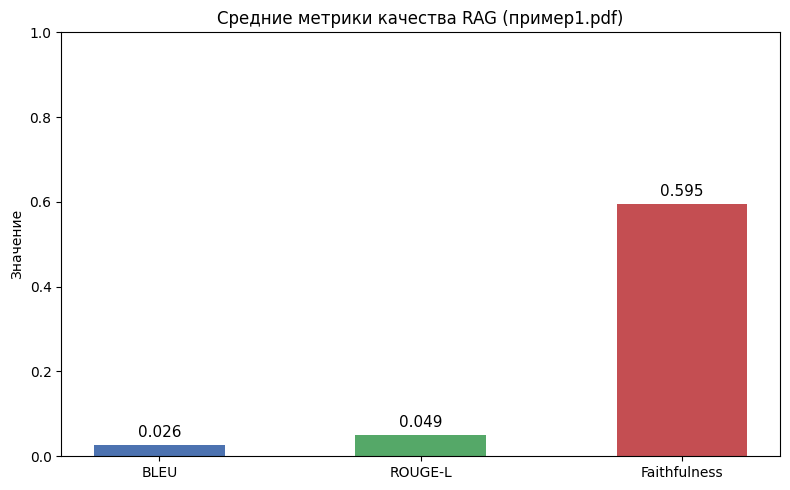

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
metric_names = ['BLEU', 'ROUGE-L', 'Faithfulness']
avg_values = [avg_bleu, avg_rouge, avg_faith]
colors = ['#4C72B0', '#55A868', '#C44E52']

bars = ax.bar(metric_names, avg_values, color=colors, width=0.5)
ax.set_ylabel('Значение')
ax.set_title('Средние метрики качества RAG (пример1.pdf)')
ax.set_ylim(0, 1.0)

for bar, val in zip(bars, avg_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
fig.savefig(os.path.join(REPORT_IMG, 'primer1_metrics.png'), dpi=150, bbox_inches='tight')
print(f'Сохранено: primer1_metrics.png')
plt.show()

---
## Итоги

В данном ноутбуке был продемонстрирован полный цикл работы мультимодальной RAG-системы на файле **пример1.pdf**:

- Извлечение и классификация структурных блоков
- Анализ изображений с помощью CLIP, BLIP, OCR и OpenCV
- Семантическое разбиение на чанки с перекрытием
- Создание мультиязычных эмбеддингов (paraphrase-multilingual-MiniLM-L12-v2)
- Индексация в FAISS и поиск релевантных фрагментов
- Генерация ответов через GPT API с оценкой качества